## Rezolvarea cerintelor pentru setul de date v2

In [1]:
# prerequisites
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model

In [2]:
# functia primeste ca parametrii un nume de fisier, dar si numele coloanelor de interes (input si output)
# se returneaza listele cu toate datele gasite pentru coloana de input, respectiv pentru coloana de output

def loadData(fileName, inputVariabName, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    selectedVariable = dataNames.index(inputVariabName)
    inputs = [float(data[i][selectedVariable]) for i in range(len(data))]
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(data[i][selectedOutput]) for i in range(len(data))]

    return inputs, outputs

# afla directorul curent (get Current Working Directory)
crtDir =  os.getcwd()
filePath = os.path.join(crtDir, 'data', 'v2_world-happiness-report-2017.csv')

inputs, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Happiness.Score')
inputs_family,outputs_family = loadData(filePath,'Family','Happiness.Score')
inputs_freedom, _ = loadData(filePath,'Freedom','Happiness.Score')

inputsCombined = [[g, f] for g, f in zip(inputs, inputs_freedom)]

Plot the data

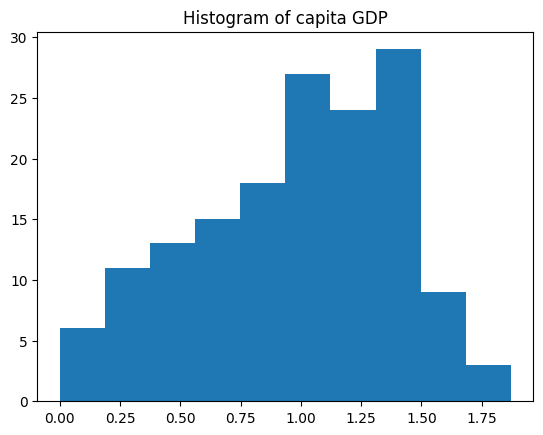

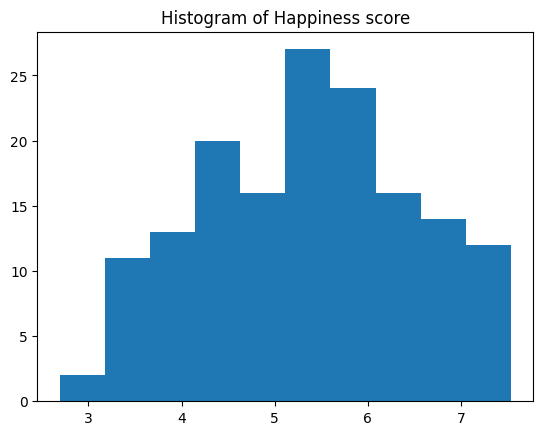

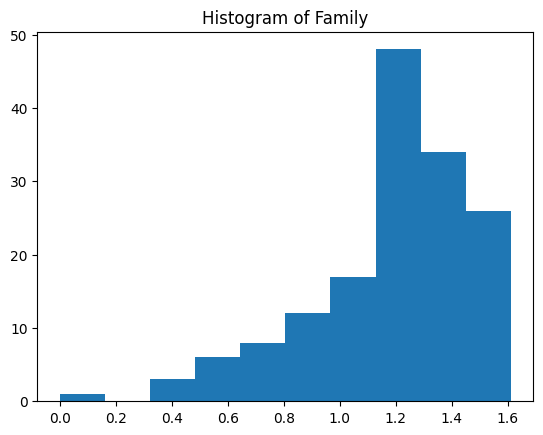

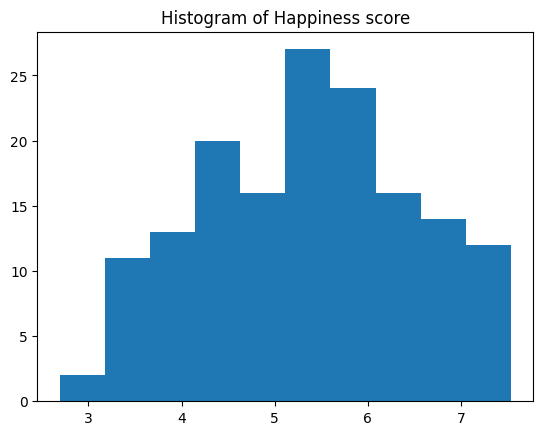

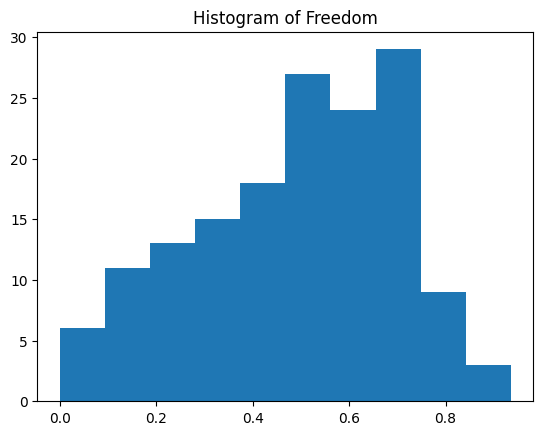

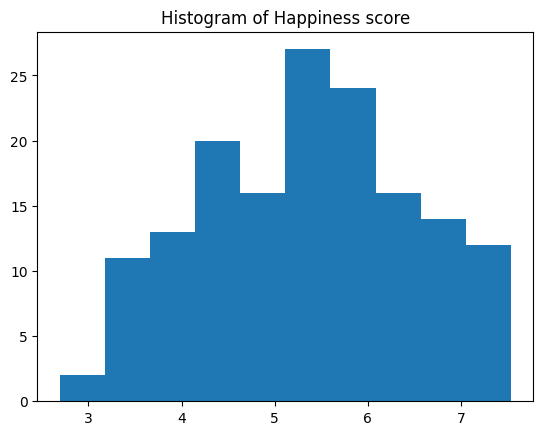

In [3]:
def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

plotDataHistogram(inputs, 'capita GDP')
plotDataHistogram(outputs, 'Happiness score')

plotDataHistogram(inputs_family, 'Family')
plotDataHistogram(outputs_family, 'Happiness score')

plotDataHistogram(inputs_freedom, 'Freedom')
plotDataHistogram(outputs, 'Happiness score')

Verificarea liniaritatii

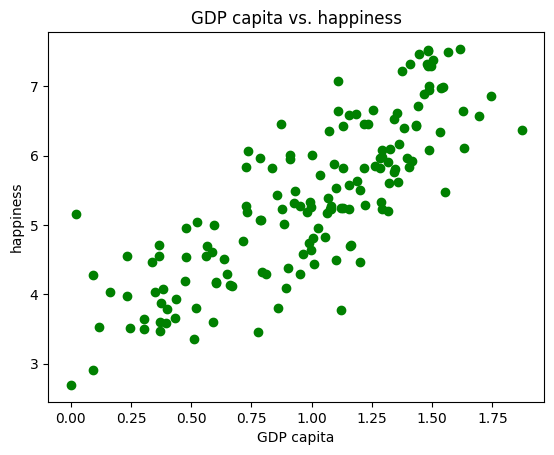

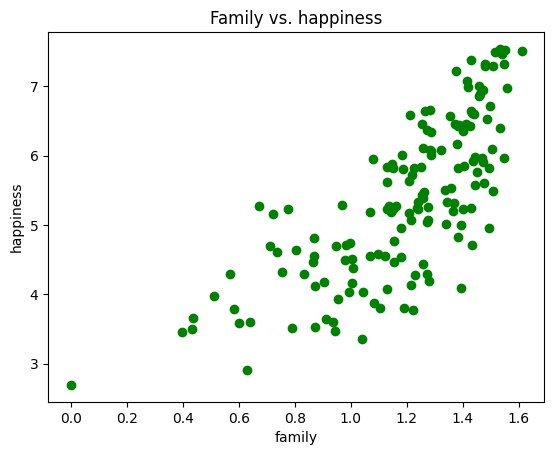

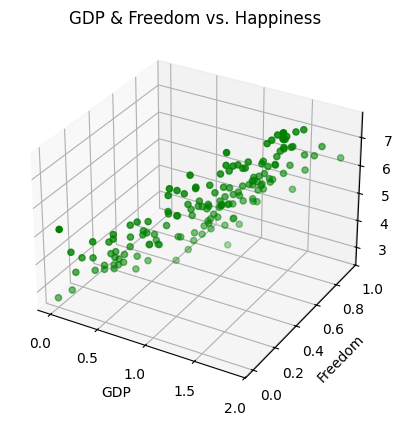

In [4]:
plt.plot(inputs, outputs, 'go')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.title('GDP capita vs. happiness')
plt.show()

plt.plot(inputs_family, outputs_family, 'go')
plt.xlabel('family')
plt.ylabel('happiness')
plt.title('Family vs. happiness')
plt.show()


gdpInput = [el[0] for el in inputsCombined]
freedomInput = [el[1] for el in inputsCombined]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(gdpInput, freedomInput, outputs, c='g', marker='o')
ax.set_xlabel('GDP')
ax.set_ylabel('Freedom')
ax.set_zlabel('Happiness')
plt.title('GDP & Freedom vs. Happiness')
plt.show()

Impartirea datelor pe train si validation

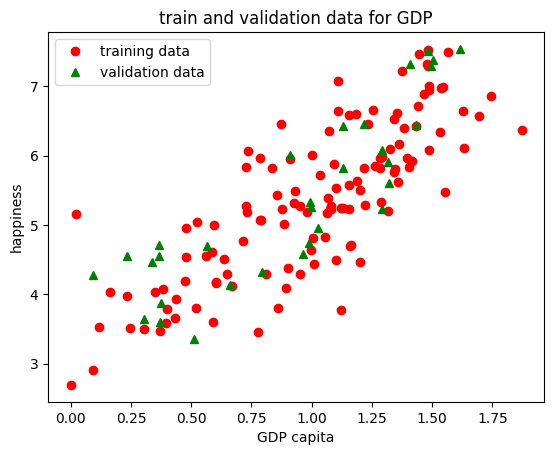

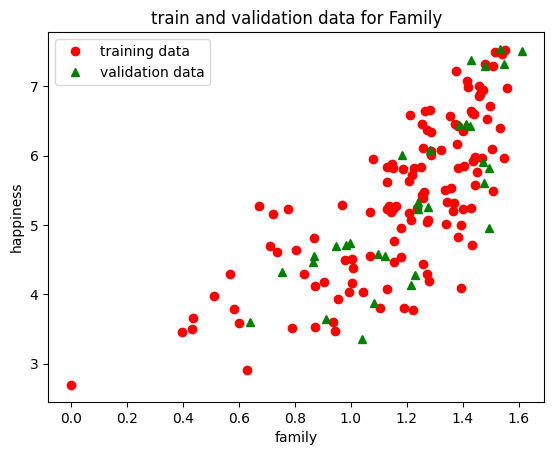

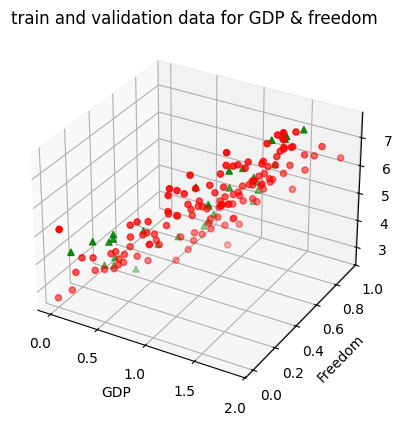

In [5]:
np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
validationSample = [i for i in indexes  if not i in trainSample]

# data pentru GDP
trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]

validationInputs = [inputs[i] for i in validationSample]
validationOutputs = [outputs[i] for i in validationSample]

# data pentru Family
trainInputsFamily = [inputs_family[i] for i in trainSample]
trainOutputsFamily = [outputs_family[i] for i in trainSample]

validationInputsFamily = [inputs_family[i] for i in validationSample]
validationOutputsFamily = [outputs_family[i] for i in validationSample]


# data pentru GDP & Freedom
trainInputsCombined = [inputsCombined[i] for i in trainSample]
trainOutputsCombined = [outputs[i] for i in trainSample]

validationInputsCombined = [inputsCombined[i] for i in validationSample]
validationOutputsCombined = [outputs[i] for i in validationSample]


# plot pentru GDP
plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')   #train data are plotted by red and circle sign
plt.plot(validationInputs, validationOutputs, 'g^', label = 'validation data')     #test data are plotted by green and a triangle sign
plt.title('train and validation data for GDP')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()

# plot pentru Family
plt.plot(trainInputsFamily, trainOutputsFamily, 'ro', label = 'training data')
plt.plot(validationInputsFamily, validationOutputsFamily, 'g^', label = 'validation data')
plt.title('train and validation data for Family')
plt.xlabel('family')
plt.ylabel('happiness')
plt.legend()
plt.show()

# plot combined

gdpTrain = [el[0] for el in trainInputsCombined]
freedomTrain = [el[1] for el in trainInputsCombined]

gdpValidation = [el[0] for el in validationInputsCombined]
freedomValidation = [el[1] for el in validationInputsCombined]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(gdpTrain, freedomTrain, trainOutputsCombined, c='r', marker='o')
ax.scatter(gdpValidation, freedomValidation, validationOutputsCombined, c='g', marker='^')
ax.set_xlabel('GDP')
ax.set_ylabel('Freedom')
ax.set_zlabel('Happiness')
plt.title('train and validation data for GDP & freedom')
plt.show()


Invatarea modelului

In [6]:
xx = [[el] for el in trainInputs]
xx_family = [[el] for el in trainInputsFamily]

#GDP

# functia de regresie
regressor = linear_model.LinearRegression()
# partea de training
regressor.fit(xx, trainOutputs)

w0, w1 = regressor.intercept_, regressor.coef_[0]
print('the learnt model for GDP: f(x) = ', w0, ' + ', w1, ' * x')


# FAMILY
regressor_family = linear_model.LinearRegression()
regressor_family.fit(xx_family, trainOutputsFamily)

w0f, w1f = regressor_family.intercept_, regressor_family.coef_[0]
print('the learnt model for Family: f(x) = ', w0f, ' + ', w1f, ' * x')


# COMBINED
regressor_combined = linear_model.LinearRegression()
regressor_combined.fit(trainInputsCombined, trainOutputsCombined)
w0c, w1c, w2c = regressor_combined.intercept_, regressor_combined.coef_[0], regressor_combined.coef_[1]
print('the learnt model for GDP & Freedom: f(x) = ', w0c, ' + ', w1c, ' * x1 +', w2c,' * x2')


the learnt model for GDP: f(x) =  3.2007686226678995  +  2.1503460961741077  * x
the learnt model for Family: f(x) =  2.039013930022846  +  2.804913617557077  * x
the learnt model for GDP & Freedom: f(x) =  3.2007585989248835  +  -68616.18596733066  * x1 + 137236.67264356057  * x2


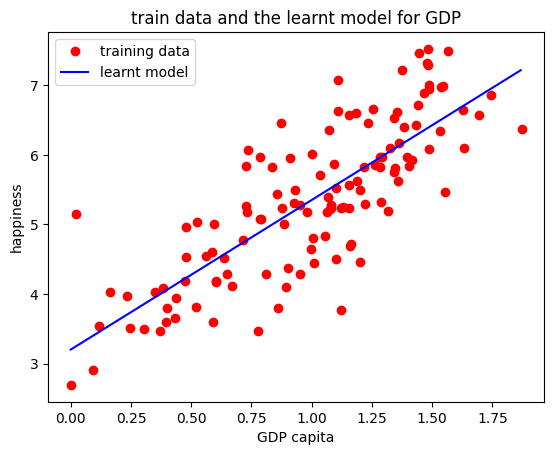

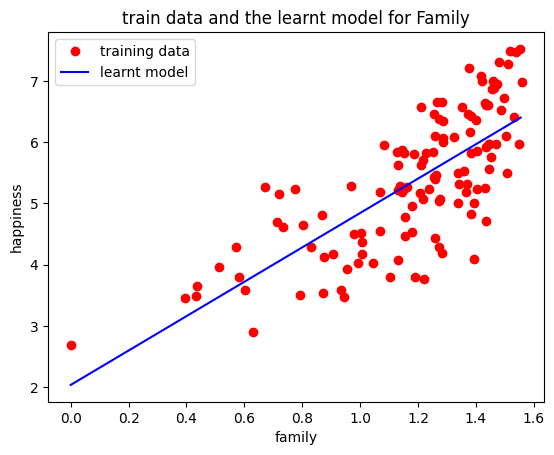

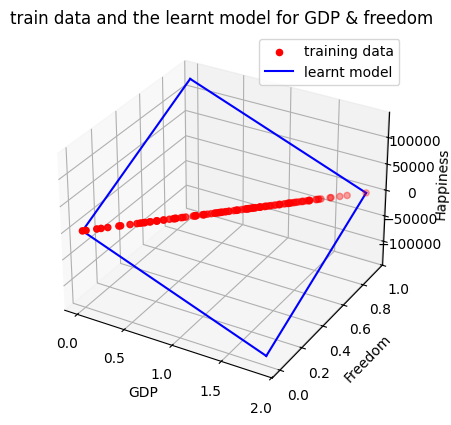

In [7]:
noOfPoints = 1000

# GDP
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = [w0 + w1 * el for el in xref]

plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')  #train data are plotted by red and circle sign
plt.plot(xref, yref, 'b-', label = 'learnt model')                  #model is plotted by a blue line
plt.title('train data and the learnt model for GDP')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()

# Family
xref1 = []
val = min(trainInputsFamily)
step = (max(trainInputsFamily) - min(trainInputsFamily)) / noOfPoints
for i in range(1, noOfPoints):
    xref1.append(val)
    val += step
yref = [w0f + w1f * el for el in xref1]

plt.plot(trainInputsFamily, trainOutputsFamily, 'ro', label = 'training data')  #train data are plotted by red and circle sign
plt.plot(xref1, yref, 'b-', label = 'learnt model')                  #model is plotted by a blue line
plt.title('train data and the learnt model for Family')
plt.xlabel('family')
plt.ylabel('happiness')
plt.legend()
plt.show()

# GDP & Freedom
# varfurile suprafetei
x_min, x_max = min(gdpTrain), max(gdpTrain)
y_min, y_max = min(freedomTrain), max(freedomTrain)

# se calculeaza si pe z
z_corner1 = w0c + w1c * x_min + w2c * y_min  # stanga-jos
z_corner2 = w0c + w1c * x_max + w2c * y_min  # dreapta-jos
z_corner3 = w0c + w1c * x_max + w2c * y_max  # dreapta-sus
z_corner4 = w0c + w1c * x_min + w2c * y_max  # stanga-sus

# deseneaza planul
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(gdpTrain, freedomTrain, trainOutputsCombined, c='r', marker='o',label='training data')
ax.set_xlabel('GDP')
ax.set_ylabel('Freedom')
ax.set_zlabel('Happiness')
plt.title('train data and the learnt model for GDP & freedom')


ax.plot([x_min, x_max], [y_min, y_min], [z_corner1, z_corner2], color='blue',label='learnt model')
ax.plot([x_max, x_max], [y_min, y_max], [z_corner2, z_corner3], color='blue')
ax.plot([x_max, x_min], [y_max, y_max], [z_corner3, z_corner4], color='blue')
ax.plot([x_min, x_min], [y_max, y_min], [z_corner4, z_corner1], color='blue')
plt.legend()
plt.show()


Predictii

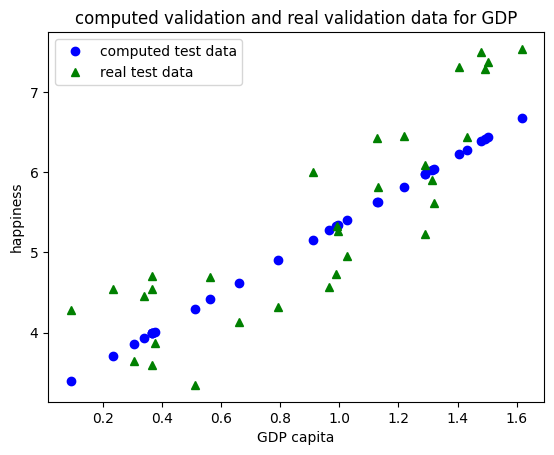

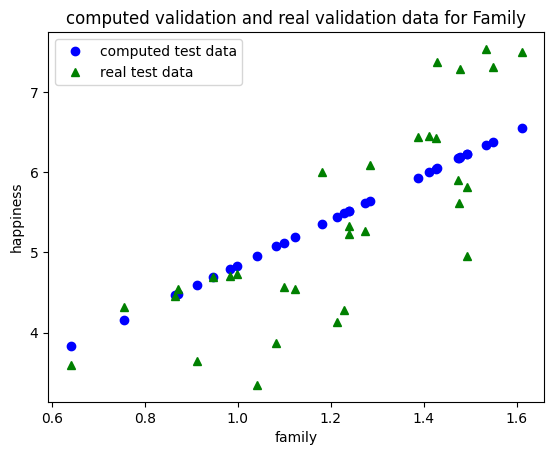

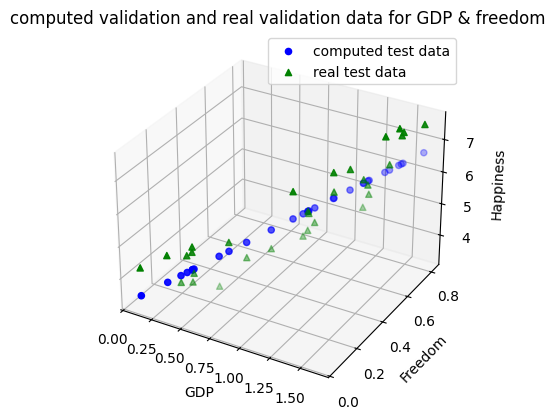

In [8]:
# GDP
computedValidationOutputs = regressor.predict([[x] for x in validationInputs])

# rezultatele obtinute de algoritmul antrenat VS rezultatele reale
plt.plot(validationInputs, computedValidationOutputs, 'bo', label = 'computed test data')
plt.plot(validationInputs, validationOutputs, 'g^', label = 'real test data')
plt.title('computed validation and real validation data for GDP')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()


# Family
computedValidationOutputsFamily = regressor_family.predict([[x] for x in validationInputsFamily])
plt.plot(validationInputsFamily, computedValidationOutputsFamily, 'bo', label = 'computed test data')
plt.plot(validationInputsFamily, validationOutputsFamily, 'g^', label = 'real test data')
plt.title('computed validation and real validation data for Family')
plt.xlabel('family')
plt.ylabel('happiness')
plt.legend()
plt.show()


# GDP & Freedom
computedValidationOutputsCombination = regressor_combined.predict([x for x in validationInputsCombined])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(gdpValidation, freedomValidation, computedValidationOutputsCombination, c='b', marker='o',label='computed test data')
ax.scatter(gdpValidation, freedomValidation, validationOutputsCombined, c='g', marker='^',label='real test data')
ax.set_xlabel('GDP')
ax.set_ylabel('Freedom')
ax.set_zlabel('Happiness')
plt.title('computed validation and real validation data for GDP & freedom')
plt.legend()
plt.show()



Performanta algoritmului

In [9]:
import math

def error_rmse(y_predicted, y_true):
    error = 0.0
    for t1,t2 in zip(y_predicted, y_true):
        error += (t1 - t2)**2
    error = error / len(y_true)
    return math.sqrt(error)

def error_modul(y_predicted, y_true):
    error = 0.0
    for t1,t2 in zip(y_predicted, y_true):
        error += abs(t1 - t2)
    error = error / len(y_true)
    return error

print("GDP Performance")
error1 = error_rmse(computedValidationOutputs, validationOutputs)
error2 = error_modul(computedValidationOutputs, validationOutputs)
print('prediction mean square error: ', error1)
print('prediction error using the mean absolute value: ', error2)


print("\nFamily Performance")
error1 = error_rmse(computedValidationOutputsFamily, validationOutputsFamily)
error2 = error_modul(computedValidationOutputsFamily, validationOutputsFamily)
print('prediction mean square error: ', error1)
print('prediction error using the mean absolute value: ', error2)


print("\nGDP & Freedom Performance")
error1 = error_rmse(computedValidationOutputsCombination, validationOutputsCombined)
error2 = error_modul(computedValidationOutputsCombination, validationOutputsCombined)
print('prediction mean square error: ', error1)
print('prediction error using the mean absolute value: ', error2)

GDP Performance
prediction mean square error:  0.6435930731840773
prediction error using the mean absolute value:  0.5588300882911795

Family Performance
prediction mean square error:  0.7778965950223466
prediction error using the mean absolute value:  0.6262605660371917

GDP & Freedom Performance
prediction mean square error:  0.6435916740853581
prediction error using the mean absolute value:  0.5588276993770549
